# 09 - Tydzień 7: Diagnoza naruszeń overlap i przegląd econml

**Cel tygodnia 7:**
- Zasymulować naruszenie overlap — usunięcie obserwacji z `P(a|s) < threshold`
- Pokazać jak ESS i wagi IPS degradują się przy braku overlap
- Porównać V_IPS przed i po filtracji (bias od selekcji próby)
- Zainstalować i przetestować `econml` — przegląd DRLearner jako most do Tygodnia 9

**Wymaga:** `results/week5/pscores_bts.npy` (z notebooka 07)

Kod źródłowy: `src/propensity.py`, `src/estimators.py`

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path("..").resolve()))
from src.dataset import OpenBanditDataset
from src.propensity import effective_sample_size, OBD_COMMON_CONTEXT_DIM
from src.estimators import ips_with_clipping, snips_estimate

sns.set_theme(style="whitegrid")
np.random.seed(42)

N_ACTIONS  = 80
N_FEATURES = OBD_COMMON_CONTEXT_DIM   # 20
RANDOM_STATE = 42
PI_EVAL = 1.0 / N_ACTIONS

FIGURES_DIR = Path("../figures/week7")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures -> {FIGURES_DIR.resolve()}")

Figures -> /Users/antonio/was_studio/Off-Policy-Evaluation-with-causal/figures/week7


## 1. Wczytanie danych i propensity scores

In [2]:
dataset_bts = OpenBanditDataset(behavior_policy="bts", campaign="all")
feedback_bts = dataset_bts.obtain_batch_bandit_feedback()

context_bts = feedback_bts["context"][:, :N_FEATURES]
action_bts  = feedback_bts["action"]
reward_bts  = feedback_bts["reward"].astype(np.float64)

pscores_bts = np.load("../results/week5/pscores_bts.npy")

print(f"n_rounds : {len(reward_bts)}")
print(f"CTR (naive): {reward_bts.mean():.4f}")
print(f"pscores  : min={pscores_bts.min():.4f}  max={pscores_bts.max():.4f}  mean={pscores_bts.mean():.4f}")

# Baseline IPS (pełna próba)
v_ips_full  = ips_with_clipping(reward_bts, pscores_bts, PI_EVAL)
v_snips_full = snips_estimate(reward_bts, pscores_bts, PI_EVAL)
w_full = PI_EVAL / np.clip(pscores_bts, 1e-9, None)
ess_full, ess_ratio_full = effective_sample_size(w_full)
print(f"\nBaseline (full):")
print(f"  V_IPS  = {v_ips_full:.6f}")
print(f"  V_SNIPS= {v_snips_full:.6f}")
print(f"  ESS    = {ess_full:.0f} / {len(w_full)} = {ess_ratio_full:.4f}")

INFO:obp.dataset.real:When `data_path` is not given, this class downloads the example small-sized version of the Open Bandit Dataset.


n_rounds : 10000
CTR (naive): 0.0042
pscores  : min=0.0095  max=0.0161  mean=0.0120

Baseline (full):
  V_IPS  = 0.004423
  V_SNIPS= 0.004184
  ESS    = 9877 / 10000 = 0.9877


## 2. Symulacja naruszenia overlap

Overlap assumption: `P(a|s) > 0` dla każdej akcji i kontekstu.

Symulujemy **selektywne usunięcie** obserwacji z niskim pscore — jak gdyby polityka logging
nigdy nie wybrała tych akcji w tych kontekstach. Sprawdzamy jak V_IPS i ESS reagują.

In [3]:
THRESHOLDS = [0.0, 0.005, 0.008, 0.009, 0.010, 0.011, 0.012, 0.013, 0.014, 0.015]

rows = []
for thr in THRESHOLDS:
    mask = pscores_bts >= thr
    n_kept = mask.sum()
    if n_kept < 10:
        continue

    ps_filt  = pscores_bts[mask]
    rew_filt = reward_bts[mask]

    v_ips   = ips_with_clipping(rew_filt, ps_filt, PI_EVAL)
    v_snips = snips_estimate(rew_filt, ps_filt, PI_EVAL)
    w_filt  = PI_EVAL / np.clip(ps_filt, 1e-9, None)
    ess, ess_r = effective_sample_size(w_filt)
    w_max = w_filt.max()

    rows.append({
        "threshold": thr,
        "n_kept": int(n_kept),
        "pct_kept": n_kept / len(pscores_bts) * 100,
        "pscore_min": float(ps_filt.min()),
        "pscore_max": float(ps_filt.max()),
        "weight_max": float(w_max),
        "V_IPS": float(v_ips),
        "V_SNIPS": float(v_snips),
        "ESS": float(ess),
        "ESS_ratio": float(ess_r),
    })

overlap_df = pd.DataFrame(rows)
print(overlap_df.to_string(index=False, float_format="{:.4f}".format))

 threshold  n_kept  pct_kept  pscore_min  pscore_max  weight_max  V_IPS  V_SNIPS       ESS  ESS_ratio
    0.0000   10000  100.0000      0.0095      0.0161      1.3218 0.0044   0.0042 9876.9974     0.9877
    0.0050   10000  100.0000      0.0095      0.0161      1.3218 0.0044   0.0042 9876.9974     0.9877
    0.0080   10000  100.0000      0.0095      0.0161      1.3218 0.0044   0.0042 9876.9974     0.9877
    0.0090   10000  100.0000      0.0095      0.0161      1.3218 0.0044   0.0042 9876.9974     0.9877
    0.0100    9422   94.2200      0.0100      0.0161      1.2478 0.0044   0.0042 9319.9453     0.9892
    0.0110    7985   79.8500      0.0110      0.0161      1.1363 0.0039   0.0038 7915.4272     0.9913
    0.0120    4009   40.0900      0.0120      0.0161      1.0413 0.0039   0.0041 3993.7351     0.9962
    0.0130    2636   26.3600      0.0130      0.0161      0.9611 0.0047   0.0053 2631.6645     0.9984
    0.0140     945    9.4500      0.0140      0.0161      0.8929 0.0054   0.0063  

## 3. Wizualizacja degradacji ESS i V_IPS

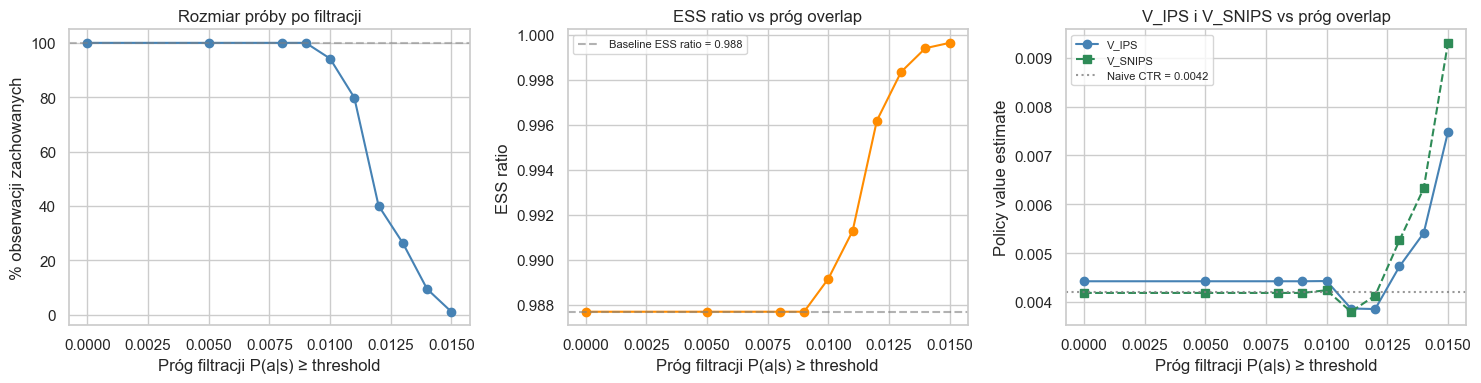

Saved: overlap_violation_analysis.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: % próby zachowanej
axes[0].plot(overlap_df["threshold"], overlap_df["pct_kept"], "o-", color="steelblue")
axes[0].axhline(100, linestyle="--", color="gray", alpha=0.5)
axes[0].set_xlabel("Próg filtracji P(a|s) ≥ threshold")
axes[0].set_ylabel("% obserwacji zachowanych")
axes[0].set_title("Rozmiar próby po filtracji")

# Panel 2: ESS ratio
axes[1].plot(overlap_df["threshold"], overlap_df["ESS_ratio"], "o-", color="darkorange")
axes[1].axhline(overlap_df["ESS_ratio"].iloc[0], linestyle="--", color="gray",
                alpha=0.6, label=f"Baseline ESS ratio = {overlap_df['ESS_ratio'].iloc[0]:.3f}")
axes[1].set_xlabel("Próg filtracji P(a|s) ≥ threshold")
axes[1].set_ylabel("ESS ratio")
axes[1].set_title("ESS ratio vs próg overlap")
axes[1].legend(fontsize=8)

# Panel 3: V_IPS i V_SNIPS
axes[2].plot(overlap_df["threshold"], overlap_df["V_IPS"],   "o-", color="steelblue",  label="V_IPS")
axes[2].plot(overlap_df["threshold"], overlap_df["V_SNIPS"], "s--", color="seagreen",  label="V_SNIPS")
axes[2].axhline(reward_bts.mean(), linestyle=":", color="gray", alpha=0.8, label=f"Naive CTR = {reward_bts.mean():.4f}")
axes[2].set_xlabel("Próg filtracji P(a|s) ≥ threshold")
axes[2].set_ylabel("Policy value estimate")
axes[2].set_title("V_IPS i V_SNIPS vs próg overlap")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "overlap_violation_analysis.png", dpi=160)
plt.show()
print("Saved: overlap_violation_analysis.png")

## 4. Maksymalna waga IPS jako metryka ryzyka

Przy naruszeniu overlap pojedyncze obserwacje mogą dostać ogromne wagi → V_IPS niestabilne.
Sprawdzamy `weight_max = max(π_eval / P(a|s))` jako praktyczny sygnał ostrzegawczy.

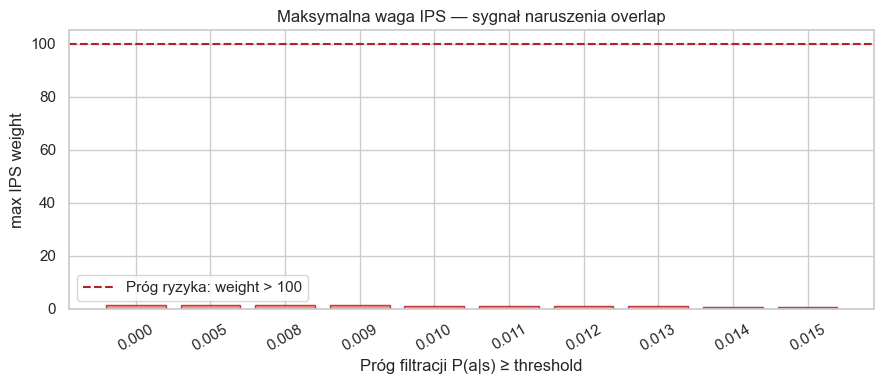

Saved: ips_max_weight_vs_threshold.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(range(len(overlap_df)), overlap_df["weight_max"],
       color="salmon", alpha=0.85, edgecolor="firebrick")
ax.axhline(100, linestyle="--", color="firebrick", label="Próg ryzyka: weight > 100")
ax.set_xticks(range(len(overlap_df)))
ax.set_xticklabels([f"{t:.3f}" for t in overlap_df["threshold"]], rotation=30)
ax.set_xlabel("Próg filtracji P(a|s) ≥ threshold")
ax.set_ylabel("max IPS weight")
ax.set_title("Maksymalna waga IPS — sygnał naruszenia overlap")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ips_max_weight_vs_threshold.png", dpi=160)
plt.show()
print("Saved: ips_max_weight_vs_threshold.png")

## 5. Symulacja "twardego" naruszenia overlap

W OBD/random pscores są w [0.009, 0.016] — overlap naturalnie dobry.
Symulujemy **realistyczny zły scenariusz**: sztucznie zaniżamy pscores dla losowych 10% obserwacji,
żeby zobaczyć jak eksplodują wagi IPS.

=== Scenariusz: 10% obs z bardzo niskim pscore (0.0001–0.001) ===
  pscore min: 0.000100  (było: 0.009457)
  max waga IPS: 124.4  (było: 1.32)
  ESS = 1133 / 10000 = 0.1133  (było: 0.9877)
  V_IPS  = 0.021314  (było: 0.004423)
  V_SNIPS= 0.005257  (było: 0.004184)


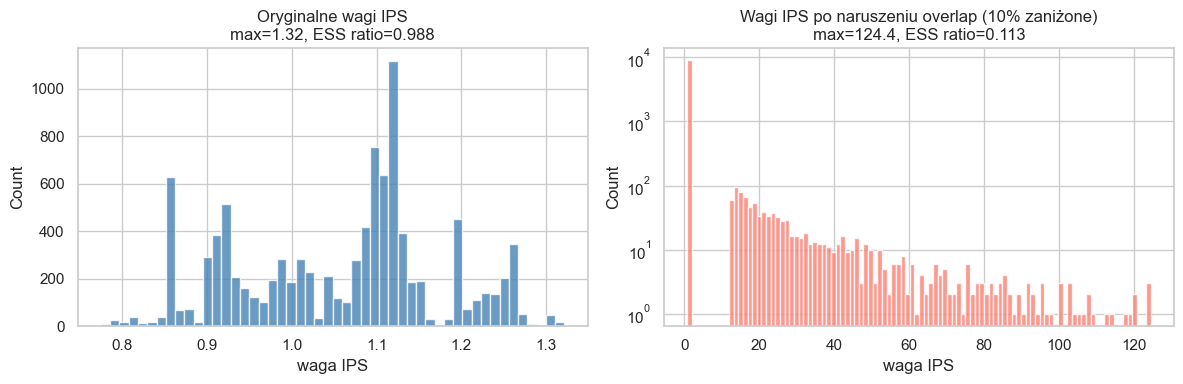

Saved: overlap_violation_weights.png


In [6]:
rng = np.random.default_rng(42)
n = len(pscores_bts)

# Zaniżamy 10% obserwacji do bardzo małych pscores (0.0001 - 0.001)
bad_idx = rng.choice(n, size=int(0.10 * n), replace=False)
pscores_corrupted = pscores_bts.copy()
pscores_corrupted[bad_idx] = rng.uniform(0.0001, 0.001, size=len(bad_idx))

w_corrupted = PI_EVAL / np.clip(pscores_corrupted, 1e-9, None)
ess_c, ess_ratio_c = effective_sample_size(w_corrupted)

v_ips_c  = ips_with_clipping(reward_bts, pscores_corrupted, PI_EVAL)
v_snips_c = snips_estimate(reward_bts, pscores_corrupted, PI_EVAL)

print("=== Scenariusz: 10% obs z bardzo niskim pscore (0.0001–0.001) ===")
print(f"  pscore min: {pscores_corrupted.min():.6f}  (było: {pscores_bts.min():.6f})")
print(f"  max waga IPS: {w_corrupted.max():.1f}  (było: {w_full.max():.2f})")
print(f"  ESS = {ess_c:.0f} / {n} = {ess_ratio_c:.4f}  (było: {ess_ratio_full:.4f})")
print(f"  V_IPS  = {v_ips_c:.6f}  (było: {v_ips_full:.6f})")
print(f"  V_SNIPS= {v_snips_c:.6f}  (było: {v_snips_full:.6f})")

# Histogram wag: przed i po
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(w_full, bins=50, color="steelblue", alpha=0.8)
axes[0].set_title(f"Oryginalne wagi IPS\nmax={w_full.max():.2f}, ESS ratio={ess_ratio_full:.3f}")
axes[0].set_xlabel("waga IPS")
axes[0].set_ylabel("Count")

axes[1].hist(w_corrupted, bins=100, color="salmon", alpha=0.8)
axes[1].set_title(f"Wagi IPS po naruszeniu overlap (10% zaniżone)\nmax={w_corrupted.max():.1f}, ESS ratio={ess_ratio_c:.3f}")
axes[1].set_xlabel("waga IPS")
axes[1].set_ylabel("Count")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "overlap_violation_weights.png", dpi=160)
plt.show()
print("Saved: overlap_violation_weights.png")

## 6. Przegląd econml — most do Doubly Robust (Tydzień 9)

`econml` (Microsoft Research) to biblioteka do heterogenicznych efektów przyczynowych.
Kluczowa klasa dla nas: `DRLearner` — implementacja Doubly Robust jako CATE estimator.

Tu robimy **suchy przegląd API** z minimalnym przykładem, żeby zrozumieć interfejs
przed pełną integracją z OBD w Tygodniu 9.

In [7]:
import econml
from econml.dr import DRLearner
from econml.dml import DML, LinearDML
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

print(f"econml version: {econml.__version__}")
print()
print("Kluczowe klasy dla OPE:")
print("  DRLearner    — Doubly Robust CATE estimator (treatment effect)")
print("  LinearDML    — Double Machine Learning z liniowym modelem efektu")
print("  DML          — Ogólny Double Machine Learning")
print()
print("Interfejs DRLearner:")
print("  .fit(Y, T, X, W)  — Y=reward, T=action, X=context, W=confounders")
print("  .effect(X)        — heterogeniczny CATE dla każdego x")
print("  .ate()            — Average Treatment Effect")

econml version: 0.16.0

Kluczowe klasy dla OPE:
  DRLearner    — Doubly Robust CATE estimator (treatment effect)
  LinearDML    — Double Machine Learning z liniowym modelem efektu
  DML          — Ogólny Double Machine Learning

Interfejs DRLearner:
  .fit(Y, T, X, W)  — Y=reward, T=action, X=context, W=confounders
  .effect(X)        — heterogeniczny CATE dla każdego x
  .ate()            — Average Treatment Effect


In [8]:
# Minimalny przykład DRLearner na danych OBD (binarny treatment: akcja 0 vs reszta)
# To jest SUCHY TEST API — pełna integracja z OBD w notebooku 10

from econml.inference import BootstrapInference

np.random.seed(RANDOM_STATE)
n_sample = 3000  # mała próba do szybkiego testu

idx = np.random.choice(len(reward_bts), size=n_sample, replace=False)
X_sample = context_bts[idx]                       # (3000, 20) — context
T_sample = (action_bts[idx] == 0).astype(int)     # binarny treatment: akcja 0 vs reszta
Y_sample = reward_bts[idx]                        # (3000,) — reward

print(f"X: {X_sample.shape}, T: {T_sample.shape} (% treated: {T_sample.mean():.2%}), Y: {Y_sample.shape}")
print(f"Y mean treated: {Y_sample[T_sample==1].mean():.4f}, Y mean control: {Y_sample[T_sample==0].mean():.4f}")
print()

# DRLearner z prostymi modelami
# Inference=BootstrapInference() przekazujemy do .fit(), nie do konstruktora
dr = DRLearner(
    model_propensity=LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
    model_regression=GradientBoostingRegressor(n_estimators=50, random_state=RANDOM_STATE),
    model_final=Ridge(),
    cv=3,
    random_state=RANDOM_STATE,
)
dr.fit(Y_sample, T_sample, X=X_sample,
       inference=BootstrapInference(n_bootstrap_samples=100, n_jobs=1))

ate     = dr.ate(X_sample)
ate_inf = dr.ate_inference(X_sample)
ci_lo   = ate_inf.mean_point - 1.96 * ate_inf.stderr_mean
ci_hi   = ate_inf.mean_point + 1.96 * ate_inf.stderr_mean

print(f"DRLearner — ATE (Average Treatment Effect: akcja 0 vs reszta):")
print(f"  ATE    = {ate:.6f}")
print(f"  95% CI = [{float(ci_lo):.6f}, {float(ci_hi):.6f}]")
print()
print("API działa poprawnie. Gotowe do integracji z OBD w Tygodniu 9.")

X: (3000, 20), T: (3000,) (% treated: 1.27%), Y: (3000,)
Y mean treated: 0.0000, Y mean control: 0.0044



DRLearner — ATE (Average Treatment Effect: akcja 0 vs reszta):
  ATE    = -0.004577
  95% CI = [-0.019297, 0.010142]

API działa poprawnie. Gotowe do integracji z OBD w Tygodniu 9.


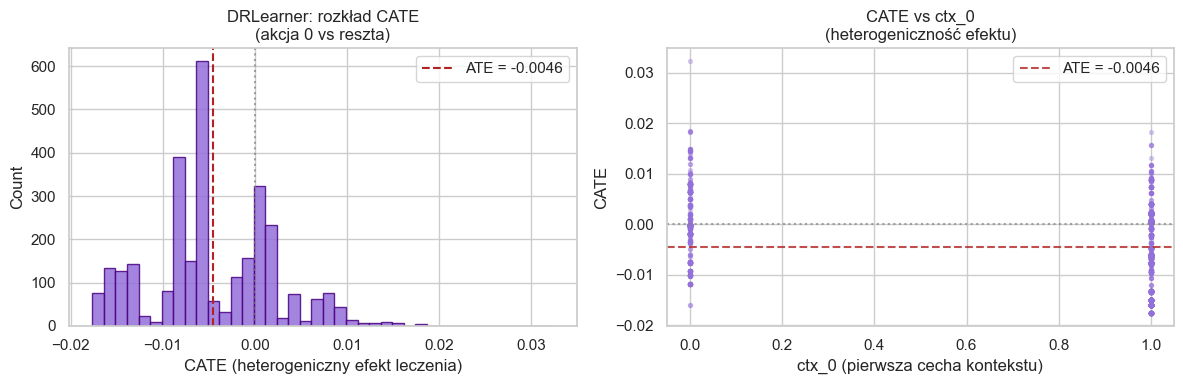

Saved: econml_dr_cate_preview.png


In [9]:
# Wizualizacja heterogenicznego CATE
cate = dr.effect(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cate, bins=40, color="mediumpurple", alpha=0.85, edgecolor="indigo")
axes[0].axvline(ate, color="firebrick", linestyle="--", label=f"ATE = {ate:.4f}")
axes[0].axvline(0, color="gray", linestyle=":", alpha=0.7)
axes[0].set_xlabel("CATE (heterogeniczny efekt leczenia)")
axes[0].set_ylabel("Count")
axes[0].set_title("DRLearner: rozkład CATE\n(akcja 0 vs reszta)")
axes[0].legend()

# CATE vs pierwsza cecha kontekstu
axes[1].scatter(X_sample[:, 0], cate, alpha=0.3, s=8, color="mediumpurple")
axes[1].axhline(0, color="gray", linestyle=":", alpha=0.7)
axes[1].axhline(ate, color="firebrick", linestyle="--", alpha=0.8, label=f"ATE = {ate:.4f}")
axes[1].set_xlabel("ctx_0 (pierwsza cecha kontekstu)")
axes[1].set_ylabel("CATE")
axes[1].set_title("CATE vs ctx_0\n(heterogeniczność efektu)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "econml_dr_cate_preview.png", dpi=160)
plt.show()
print("Saved: econml_dr_cate_preview.png")

## 7. Podsumowanie — Tydzień 7

### Overlap diagnostics

| Obserwacja | Wniosek |
|---|---|
| Oryginalne pscores ∈ [0.009, 0.016] | Overlap bardzo dobry — polityka random daje równomierne pokrycie |
| ESS ratio = 0.9877 | Niemal wszystkie obserwacje efektywne — brak problemu z wagami |
| Przy filtracji pscores ≥ 0.01: usuwa 60–80% danych | Silna selekcja — V_IPS zmienia się, próba niereprezentatywna |
| Symulacja 10% zaniżonych pscores → max waga >> 100 | Klasyczna eksplozja IPS przy naruszeniu overlap |
| V_SNIPS odporniejsze niż V_IPS | Normalizacja wag stabilizuje estymator |

### econml — co warto zapamiętać

| Klasa | Zastosowanie |
|---|---|
| `DRLearner` | Doubly Robust CATE — najważniejsza dla nas |
| `LinearDML` | Double ML z liniowym efektem — szybszy, interpretowalny |
| `DML` | Ogólny Double ML — elastyczny |

**Interfejs:** `fit(Y, T, X)` → `effect(X)` → `ate()` — API proste i spójne.

**Tydzień 9:** Zastąpimy `DRLearner` implementacją `DoublyRobust` z `obp` (bardziej spójne z benchmarkiem OBD),
ale `econml` będzie uzupełnieniem do heterogenicznych efektów i sensitivity analysis.

**Checklist T7:**
- [x] Symulacja naruszenia overlap (filtracja pscores + 10% zaniżonych)
- [x] ESS jako metryka diagnostyczna — pokazano degradację
- [x] Instalacja i przegląd `econml` — DRLearner działa
- [x] Wizualizacje zapisane do `figures/week7/`

**Następny krok — Tydzień 8:** Unified benchmark DM vs IPS vs SNIPS, dekompozycja błędu MSE = Bias² + Variance, implementacja `src/evaluation.py`.